# Case 6: Klastering Radius Pemasaran & Distribusi Geografis

Meneliti apakah ada korelasi antara wilayah kecamatan tempat UMKM beroperasi dengan seberapa jauh produk mereka dipasarkan (lokal/nasional/ekspor).

**Fokus Fitur yang Digunakan:**
- Tujuan Pemasaran Numeric
- Kecamatan Numeric
- Ekspor Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [3]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Tujuan Pemasaran Numeric', 'Kecamatan Numeric', 'Ekspor Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Tujuan Pemasaran Numeric,Kecamatan Numeric,Ekspor Numeric
0,NASYWA SNACK,0,50,1
1,WARUNG ABINAYA,6,6,1
2,TUNGKU MA ENDANG,8,6,1
3,WARUNG BU WIWIK,7,22,1
4,WARUNG PNUNG,6,17,1


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


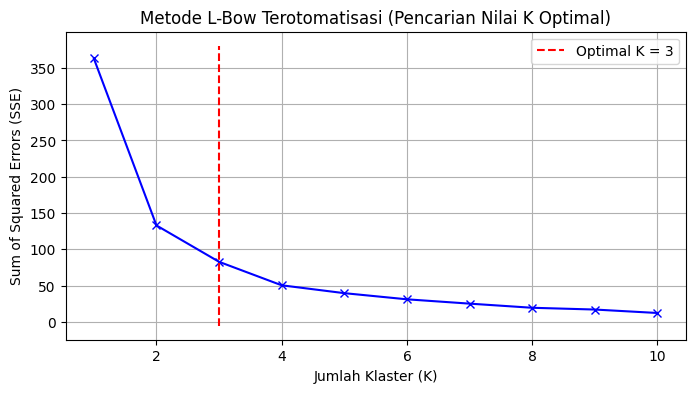

Rekomendasi K-Optimal adalah: 3


In [4]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi Hybrid CSA-KMeans

In [5]:
print(f"Memulai Pencarian Sarang Global (CSA) untuk K={optimal_k}...")
best_cuckoo_centroids_scaled, _ = cuckoo_search_kmeans(X_scaled, k=optimal_k, n_nests=10, max_iter=30, pa=0.25)

print("Mengeksekusi K-Means Final...")
final_labels, final_centroids_scaled = final_kmeans(X_scaled, best_cuckoo_centroids_scaled)

df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Memulai Pencarian Sarang Global (CSA) untuk K=3...
Mengeksekusi K-Means Final...


,Nama Usaha,Tujuan Pemasaran Numeric,Kecamatan Numeric,Ekspor Numeric,Cluster
0,NASYWA SNACK,0,50,1,C3
1,WARUNG ABINAYA,6,6,1,C2
2,TUNGKU MA ENDANG,8,6,1,C2
3,WARUNG BU WIWIK,7,22,1,C2
4,WARUNG PNUNG,6,17,1,C2
5,KRISNA TRANSPORT,0,26,1,C2
6,LAUNDRY WINA,6,6,1,C2
7,JP CATERING,6,50,1,C3
8,SANDANG TRIAN,7,17,1,C2
9,JUALAN ES KELAPA MUDA,6,52,1,C3


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


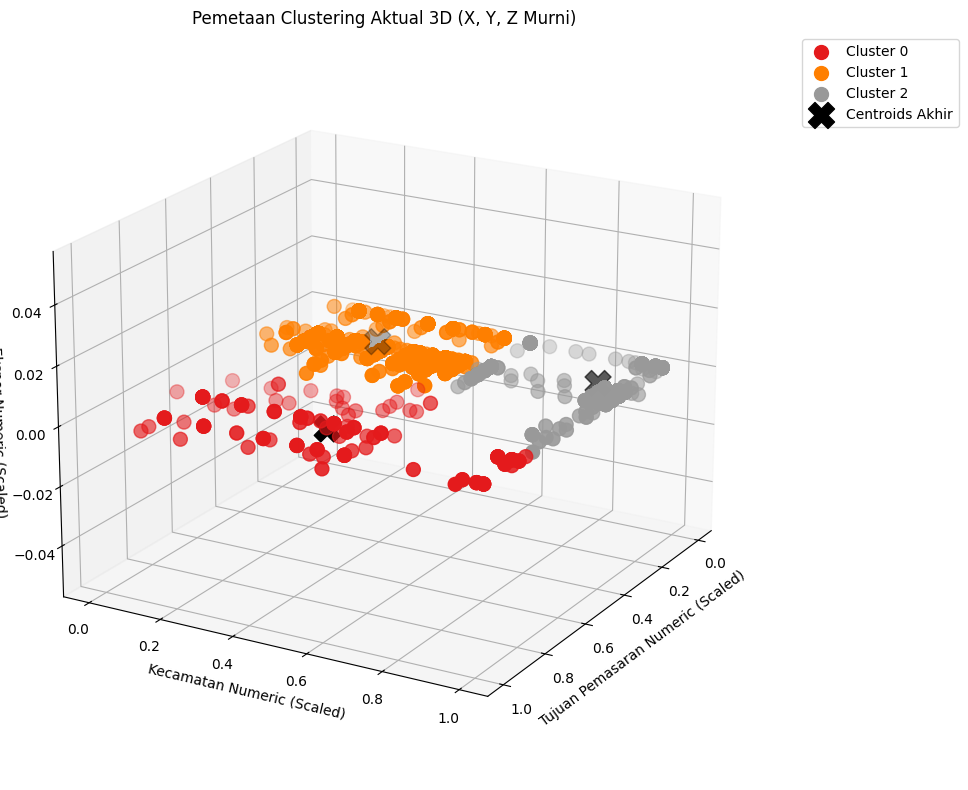


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.6334
   [Interpretasi]: BUKTINYA BAIK. Terdapat struktur klaster yang masuk akal.

2. Davies-Bouldin Index (DBI): 0.6199
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 4425.1509
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 82.8093
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.1903
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [6]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [7]:
import plotly.express as px

# =========================================================
# 1. Visualisasi 3D Interaktif (Pemasaran vs Kecamatan vs Ekspor)
# =========================================================
fig_3d_c6 = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Tujuan Pemasaran Numeric
    y=fitur_yang_dipakai[1], # Kecamatan Numeric
    z=fitur_yang_dipakai[2], # Ekspor Numeric
    color='Cluster',
    hover_name='Nama Usaha',
    title="Peta 3D: Hubungan Kecamatan dan Target Pasar (Lokal/Ekspor)",
    opacity=0.8,
    size_max=12,
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig_3d_c6.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d_c6.show()


# =========================================================
# 2. Bar Chart (Pembandingan Profil Rata-rata Geografis)
# =========================================================
# Mengambil rata-rata metrik dari setiap klaster
df_avg_c6 = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Melakukan transformasi data (melt)
df_melted_c6 = df_avg_c6.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Dimensi', value_name='Nilai Rata-rata')

# Menggambar diagram batang
fig_bar_c6 = px.bar(
    df_melted_c6, 
    x='Cluster', 
    y='Nilai Rata-rata', 
    color='Dimensi', 
    barmode='group',
    title="Profil Rata-rata Sebaran Pemasaran per Klaster"
)
fig_bar_c6.show()
